In [1]:
# Uncomment and run:
!pip install pydicom numpy matplotlib opencv-python-headless Pillow
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install "ipympl==0.9.4"                 # for interactive matplotlib in Colab
!pip install git+https://github.com/facebookresearch/segment-anything.git

# Clone MedSAM repo (contains the model definition)
!git clone https://github.com/bowang-lab/MedSAM.git
%cd MedSAM

# Download the ViT-B checkpoint (~375 MB)
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth \
     -O medsam_vit_b.pth
# NOTE: For the MedSAM fine-tuned checkpoint, replace with the correct URL
# when publicly available. The SAM ViT-B checkpoint works as a base.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.4 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.3/516.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.8 MB/s eta 0:00:00
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-u76p41qg
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-u76p41qg
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=a36a69275277c693b5dd0f99cee18a27ae1497c7c0cc0cf3e85a1028b056885f
  Stored in directory: /tmp/pip-ephem-wheel-cache-xe_8z05n/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully b

In [2]:
import os
import sys
import numpy as np
import matplotlib
# matplotlib.use("nbagg")   # interactive backend for Colab
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import RectangleSelector
import cv2
import pydicom
from pydicom.pixels import apply_voi_lut # Updated import for future compatibility
from PIL import Image
import torch
import torch.nn.functional as F

sys.path.append("/content/MedSAM")           # adjust if your path differs
from segment_anything import sam_model_registry, SamPredictor

# ─ Reproducibility ──────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


In [12]:
def load_dicom(dcm_path: str):
    """
    Load a DICOM file and return:
        pixel_array_norm : float32 array normalised to [0, 255]  (H, W)
        img_rgb          : uint8 RGB array  (H, W, 3)  — ready for MedSAM
        mm_per_pixel_x   : physical width  of one pixel in mm
        mm_per_pixel_y   : physical height of one pixel in mm
        ds               : raw pydicom Dataset (for debugging)
    """
    ds = pydicom.dcmread(dcm_path)
    print(f"[DICOM] File      : {os.path.basename(dcm_path)}")
    print(f"[DICOM] Modality  : {getattr(ds, 'Modality', 'N/A')}")
    print(f"[DICOM] Rows×Cols : {ds.Rows} × {ds.Columns}")
    print(f"[DICOM] BitsStored: {getattr(ds, 'BitsStored', 'N/A')}")

    # ── Pixel extraction ───────────────────────────────────────────────────
    try:
      pixel_array = ds.pixel_array.astype(np.float32)
    except ValueError:
      print("[DICOM] Retrying with force=True (annotated/overlay image)")
      ds2 = pydicom.dcmread(dcm_path, force=True)
      ds2.file_meta.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian
      pixel_array = ds2.pixel_array.astype(np.float32)

    # Apply VOI LUT (window/level) if present AND if photometric interpretation is monochrome
    if hasattr(ds, "WindowCenter") and hasattr(ds, "WindowWidth"):
        if getattr(ds, "PhotometricInterpretation", "") in ["MONOCHROME1", "MONOCHROME2"]:
            pixel_array = apply_voi_lut(pixel_array, ds)
            print("[DICOM] VOI LUT applied (window/level)")
        else:
            print("[DICOM] Skipping VOI LUT: Not a monochrome image.")

    # Handle multi-frame: RGB ultrasound is (H, W, 3) — do NOT slice frame
    if pixel_array.ndim == 3 and pixel_array.shape[2] == 3:
        # Already (H, W, 3) RGB — use as is
        pass
    elif pixel_array.ndim == 3 and pixel_array.shape[0] > 1:
        # Multi-frame grayscale — take first frame
        pixel_array = pixel_array[0]
        print(f"[DICOM] Multi-frame grayscale — using frame 0")

    # Normalise to 0–255
    p_min, p_max = pixel_array.min(), pixel_array.max()
    pixel_norm = ((pixel_array - p_min) / (p_max - p_min + 1e-8) * 255).astype(np.uint8)

    # Convert to RGB (MedSAM expects 3-channel input)
    if pixel_norm.ndim == 2:
        img_rgb = np.stack([pixel_norm] * 3, axis=-1)
    elif pixel_norm.shape[-1] == 1:
        img_rgb = np.concatenate([pixel_norm] * 3, axis=-1)
    else:
        img_rgb = pixel_norm                # already RGB

    # ── Spatial resolution ─────────────────────────────────────────────────
    mm_per_pixel_x, mm_per_pixel_y = extract_spatial_resolution(ds)
    print(f"[DICOM] Resolution: {mm_per_pixel_x:.4f} mm/px (X)  |  "
          f"{mm_per_pixel_y:.4f} mm/px (Y)")

    return pixel_norm, img_rgb, mm_per_pixel_x, mm_per_pixel_y, ds


def extract_spatial_resolution(ds):
    """
    Try to extract mm/pixel from multiple DICOM sources, in priority order.
    Returns (mm_per_pixel_x, mm_per_pixel_y).
    Falls back to (0.1, 0.1) with a warning if nothing is found.
    """

    # ── Priority 1: SequenceOfUltrasoundRegions (0018,6011) ────────────────
    # The most accurate source for ultrasound spatial calibration.
    uregion_tag = (0x0018, 0x6011)
    if uregion_tag in ds:
        regions = ds[uregion_tag].value
        if regions:
            r = regions[0]                       # use first region
            phys_dx = getattr(r, "PhysicalDeltaX", None)
            phys_dy = getattr(r, "PhysicalDeltaY", None)
            unit_x  = getattr(r, "PhysicalUnitsXDirection", None)
            unit_y  = getattr(r, "PhysicalUnitsYDirection", None)

            if phys_dx and phys_dy:
                # DICOM unit code 0003 = cm, 0004 = mm
                # Convert cm → mm if needed
                conv_x = 10.0 if unit_x == 3 else 1.0
                conv_y = 10.0 if unit_y == 3 else 1.0
                return float(phys_dx) * conv_x, float(phys_dy) * conv_y

    # ── Priority 2: PixelSpacing ────────────────────────────────────────────
    if hasattr(ds, "PixelSpacing"):
        ps = ds.PixelSpacing
        return float(ps[1]), float(ps[0])     # [row spacing, col spacing]

    # ── Priority 3: ImagerPixelSpacing ─────────────────────────────────────
    if hasattr(ds, "ImagerPixelSpacing"):
        ips = ds.ImagerPixelSpacing
        return float(ips[1]), float(ips[0])

    # ── Fallback ────────────────────────────────────────────────────────────
    print("[WARNING] No spatial calibration found in DICOM tags. "
          "Defaulting to 0.1 mm/px — measurements will be approximate.")
    return 0.1, 0.1


# ─ Example usage (replace with your actual file path) ───────────────────────
DCM_PATH = "/content/202603121732490198VAS.DCM"        # ← change this

pixel_norm, img_rgb, mm_per_pixel_x, mm_per_pixel_y, ds = load_dicom(DCM_PATH)
print(f"\n[INFO] Image shape (H×W×C): {img_rgb.shape}")

[DICOM] File      : 202603121732490198VAS.DCM
[DICOM] Modality  : US
[DICOM] Rows×Cols : 920 × 1260
[DICOM] BitsStored: 8
[DICOM] Skipping VOI LUT: Not a monochrome image.
[DICOM] Resolution: 0.0501 mm/px (X)  |  0.0501 mm/px (Y)

[INFO] Image shape (H×W×C): (920, 1260, 3)



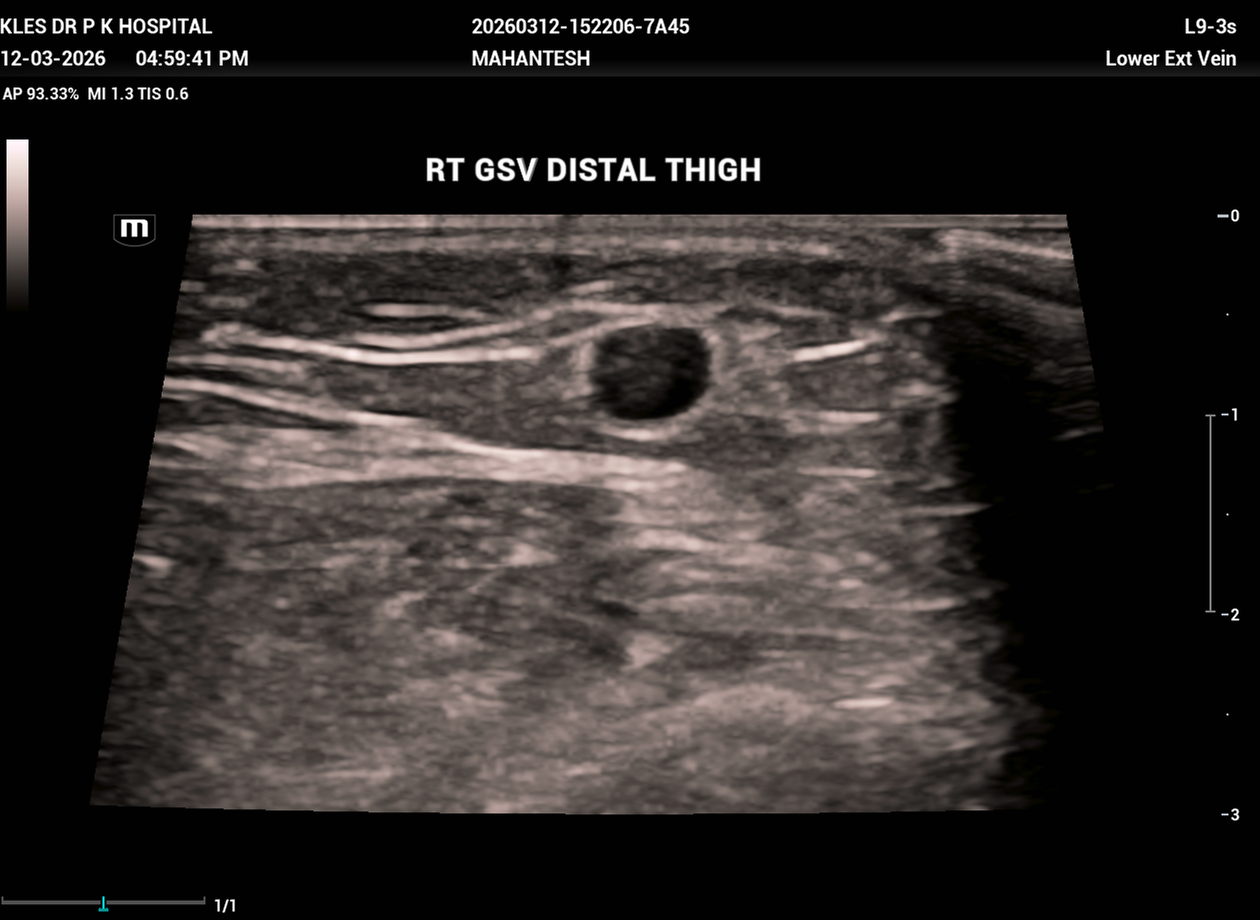


[INFO] 1) Draw a bounding box around the vein lumen.
[INFO] 2) Optionally add +Point INSIDE the dark lumen (foreground).
[INFO] 3) Optionally add -Point on bright wall tissue (background).
[INFO] 4) Run the next cell when ready.
[PROMPT] bbox=[544, 297, 746, 450]  +pts=0  -pts=0
[PROMPT] bbox=[544, 297, 746, 450]  +pts=1  -pts=0
[PROMPT] bbox=[544, 297, 746, 450]  +pts=1  -pts=1
[PROMPT] bbox=[544, 297, 746, 450]  +pts=1  -pts=2
[PROMPT] bbox=[544, 297, 746, 450]  +pts=1  -pts=3
[PROMPT] bbox=[544, 297, 746, 450]  +pts=1  -pts=4


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Interactive prompt builder: bounding box + positive/negative points
#
# MODES (toggle with the buttons on-canvas):
#   [BBOX]   — click & drag to draw the bounding box
#   [+Point] — single click to add a foreground (positive) point (green dot)
#   [-Point] — single click to add a background (negative) point (red dot)
#   [Clear]  — reset everything
#
# After interacting, run the next cell to confirm.
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import output
from IPython.display import display, HTML
from io import BytesIO
from PIL import Image as PILImage
import base64, json as _json

# ── Shared state ─────────────────────────────────────────────────────────────
prompt_state = {
    "bbox"      : None,        # [x1, y1, x2, y2]  or None
    "pos_points": [],          # list of [x, y]
    "neg_points": [],          # list of [x, y]
}

# ── Encode image for canvas ───────────────────────────────────────────────────
_buf = BytesIO()
PILImage.fromarray(img_rgb).save(_buf, format="PNG")
img_b64 = base64.b64encode(_buf.getvalue()).decode()
H, W    = img_rgb.shape[:2]

html = f"""
<style>
  #toolbar {{ margin-bottom:6px; }}
  .btn {{
    padding:6px 14px; margin-right:6px; border:none; border-radius:4px;
    font-weight:bold; cursor:pointer; font-size:13px;
  }}
  #btnBbox  {{ background:#00e5ff; color:#000; }}
  #btnPos   {{ background:#00e676; color:#000; }}
  #btnNeg   {{ background:#ff1744; color:#fff; }}
  #btnClear {{ background:#888;    color:#fff; }}
  #status   {{ margin-top:6px; font-weight:bold; font-size:13px; color:#ffe082; }}
</style>

<div id="toolbar">
  <button class="btn" id="btnBbox"  onclick="setMode('bbox')" >📦 BBOX</button>
  <button class="btn" id="btnPos"   onclick="setMode('pos')"  >➕ +Point</button>
  <button class="btn" id="btnNeg"   onclick="setMode('neg')"  >➖ -Point</button>
  <button class="btn" id="btnClear" onclick="clearAll()"      >🗑 Clear</button>
</div>
<canvas id="cv" width="{W}" height="{H}"
  style="border:2px solid #00FF7F; cursor:crosshair; max-width:100%;"></canvas>
<div id="status">Mode: BBOX — click & drag to draw bounding box</div>

<script>
const cv  = document.getElementById('cv');
const ctx = cv.getContext('2d');
const baseImg = new Image();
baseImg.src = 'data:image/png;base64,{img_b64}';

let mode  = 'bbox';
let sx, sy, drawing = false;
let bbox  = null;
let pos   = [];
let neg   = [];

baseImg.onload = () => redraw();

function setMode(m) {{
  mode = m;
  const labels = {{ bbox:'BBOX — click & drag', pos:'+Point — click foreground', neg:'-Point — click background' }};
  document.getElementById('status').innerText = 'Mode: ' + (labels[m] || m);
}}

function clearAll() {{
  bbox = null; pos = []; neg = [];
  redraw();
  document.getElementById('status').innerText = 'Cleared. Mode: ' + mode;
  google.colab.kernel.invokeFunction('update_prompt', [null, [], []], {{}});
}}

function redraw() {{
  ctx.clearRect(0, 0, cv.width, cv.height);
  ctx.drawImage(baseImg, 0, 0);

  // Draw bbox
  if (bbox) {{
    ctx.strokeStyle = '#00FF7F'; ctx.lineWidth = 2;
    ctx.strokeRect(bbox[0], bbox[1], bbox[2]-bbox[0], bbox[3]-bbox[1]);
    ctx.fillStyle = 'rgba(0,255,127,0.08)';
    ctx.fillRect(bbox[0], bbox[1], bbox[2]-bbox[0], bbox[3]-bbox[1]);
  }}

  // Draw positive points (green)
  pos.forEach(([x,y]) => {{
    ctx.beginPath(); ctx.arc(x, y, 6, 0, 2*Math.PI);
    ctx.fillStyle = '#00e676'; ctx.fill();
    ctx.strokeStyle = '#fff'; ctx.lineWidth = 1.5; ctx.stroke();
    ctx.fillStyle = '#fff'; ctx.font = 'bold 10px sans-serif';
    ctx.textAlign = 'center'; ctx.textBaseline = 'middle';
    ctx.fillText('+', x, y);
  }});

  // Draw negative points (red)
  neg.forEach(([x,y]) => {{
    ctx.beginPath(); ctx.arc(x, y, 6, 0, 2*Math.PI);
    ctx.fillStyle = '#ff1744'; ctx.fill();
    ctx.strokeStyle = '#fff'; ctx.lineWidth = 1.5; ctx.stroke();
    ctx.fillStyle = '#fff'; ctx.font = 'bold 10px sans-serif';
    ctx.textAlign = 'center'; ctx.textBaseline = 'middle';
    ctx.fillText('−', x, y);
  }});
}}

function getXY(e) {{
  const r = cv.getBoundingClientRect();
  return [
    Math.round((e.clientX - r.left)  * cv.width  / r.width),
    Math.round((e.clientY - r.top)   * cv.height / r.height)
  ];
}}

cv.onmousedown = e => {{
  const [x, y] = getXY(e);
  if (mode === 'bbox') {{ sx = x; sy = y; drawing = true; }}
  else if (mode === 'pos') {{
    pos.push([x, y]); redraw();
    google.colab.kernel.invokeFunction('update_prompt', [bbox, pos, neg], {{}});
    document.getElementById('status').innerText =
      `+Point added at (${{x}},${{y}}) — total: ${{pos.length}} pos, ${{neg.length}} neg`;
  }} else if (mode === 'neg') {{
    neg.push([x, y]); redraw();
    google.colab.kernel.invokeFunction('update_prompt', [bbox, pos, neg], {{}});
    document.getElementById('status').innerText =
      `-Point added at (${{x}},${{y}}) — total: ${{pos.length}} pos, ${{neg.length}} neg`;
  }}
}};

cv.onmousemove = e => {{
  if (!drawing || mode !== 'bbox') return;
  const [cx, cy] = getXY(e);
  redraw();
  ctx.strokeStyle = '#00FF7F'; ctx.lineWidth = 2;
  ctx.strokeRect(sx, sy, cx-sx, cy-sy);
}};

cv.onmouseup = e => {{
  if (!drawing || mode !== 'bbox') return;
  const [ex, ey] = getXY(e);
  drawing = false;
  bbox = [Math.min(sx,ex), Math.min(sy,ey), Math.max(sx,ex), Math.max(sy,ey)];
  redraw();
  google.colab.kernel.invokeFunction('update_prompt', [bbox, pos, neg], {{}});
  document.getElementById('status').innerText =
    `BBOX set: [${{bbox}}] — add +/− points or run next cell`;
}};
</script>
"""

def update_prompt_callback(bbox_arg, pos_arg, neg_arg):
    prompt_state["bbox"]       = bbox_arg
    prompt_state["pos_points"] = pos_arg  or []
    prompt_state["neg_points"] = neg_arg  or []
    print(f"[PROMPT] bbox={bbox_arg}  +pts={len(pos_arg or [])}  -pts={len(neg_arg or [])}")

output.register_callback('update_prompt', update_prompt_callback)
display(HTML(html))
print("\n[INFO] 1) Draw a bounding box around the vein lumen.")
print("[INFO] 2) Optionally add +Point INSIDE the dark lumen (foreground).")
print("[INFO] 3) Optionally add -Point on bright wall tissue (background).")
print("[INFO] 4) Run the next cell when ready.")


[CONFIRM] bounding_box : [544, 297, 746, 450]
[CONFIRM] pos_points   : [[649, 374]]  (1 foreground)
[CONFIRM] neg_points   : [[564, 373], [647, 306], [734, 368], [652, 431]]  (4 background)


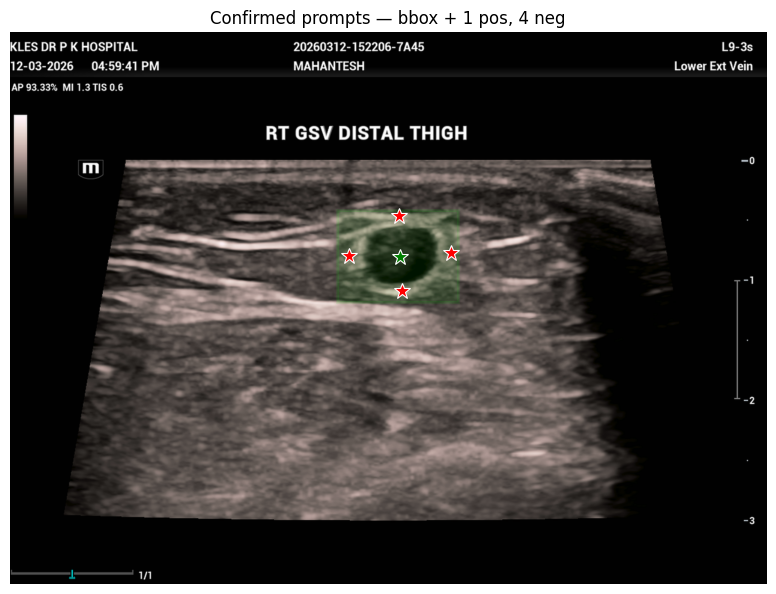

In [13]:
# ── Confirm prompt — apply fallback if canvas callback was too slow ──────────
H, W = img_rgb.shape[:2]

# Fallback bbox if none drawn
if prompt_state["bbox"] is None:
    prompt_state["bbox"] = [100, 100, 300, 250]
    print("[WARN] No bbox captured — using fallback. Update values above or re-draw.")

x1, y1, x2, y2 = [int(v) for v in prompt_state["bbox"]]
x1, y1 = max(0, x1), max(0, y1)
x2, y2 = min(W, x2), min(H, y2)

bounding_box = np.array([x1, y1, x2, y2])

pos_points = [[int(p[0]), int(p[1])] for p in prompt_state["pos_points"]]
neg_points = [[int(p[0]), int(p[1])] for p in prompt_state["neg_points"]]

print(f"[CONFIRM] bounding_box : {bounding_box.tolist()}")
print(f"[CONFIRM] pos_points   : {pos_points}  ({len(pos_points)} foreground)")
print(f"[CONFIRM] neg_points   : {neg_points}  ({len(neg_points)} background)")

# Preview
import matplotlib.patches as patches
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.imshow(img_rgb, cmap="gray" if img_rgb.ndim == 2 else None)
rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                           linewidth=2, edgecolor="lime", facecolor="lime", alpha=0.08)
ax2.add_patch(rect)
for (px, py) in pos_points:
    ax2.plot(px, py, 'g*', markersize=12, markeredgecolor='white', markeredgewidth=0.8)
for (px, py) in neg_points:
    ax2.plot(px, py, 'r*', markersize=12, markeredgecolor='white', markeredgewidth=0.8)
ax2.set_title(f"Confirmed prompts — bbox + {len(pos_points)} pos, {len(neg_points)} neg")
ax2.axis("off")
plt.tight_layout()
plt.show()


In [6]:
# from google.colab import output
# output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [7]:
# from google.colab import output
# output.disable_custom_widget_manager()

In [14]:
CHECKPOINT_PATH = "/content/MedSAM/medsam_vit_b.pth"

print(f"[MODEL] Loading MedSAM ViT-B checkpoint from:\n  {CHECKPOINT_PATH}")

sam = sam_model_registry["vit_b"](checkpoint=CHECKPOINT_PATH)
sam.to(DEVICE)
sam.eval()

predictor = SamPredictor(sam)
print("[MODEL] MedSAM loaded successfully ✓")
print(f"[MODEL] Parameters: {sum(p.numel() for p in sam.parameters()):,}")

[MODEL] Loading MedSAM ViT-B checkpoint from:
  /content/MedSAM/medsam_vit_b.pth
[MODEL] MedSAM loaded successfully ✓
[MODEL] Parameters: 93,735,472


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL — Predict with MedSAM
#
# Strategy for dark (anechoic) lumen segmentation:
#   1. Run predictor.predict() with bbox + any user-supplied point prompts.
#   2. SAM naturally tends to segment the *bright* echogenic wall.
#      → We detect this and invert the mask so we capture the dark lumen.
#   3. The inversion is done only INSIDE the bounding box to avoid noise.
# ─────────────────────────────────────────────────────────────────────────────

predictor.set_image(img_rgb)

# ── Build point-prompt arrays ────────────────────────────────────────────────
all_points = pos_points + neg_points
all_labels = [1] * len(pos_points) + [0] * len(neg_points)

point_coords = np.array(all_points, dtype=np.float32) if all_points else None
point_labels = np.array(all_labels, dtype=np.int32)   if all_points else None

# ── Run prediction ────────────────────────────────────────────────────────────
masks, scores, logits = predictor.predict(
    box             = bounding_box,
    point_coords    = point_coords,
    point_labels    = point_labels,
    multimask_output= True,
)

best_mask_idx   = np.argmax(scores)
mask_raw        = masks[best_mask_idx]   # what SAM grabbed
confidence_score= scores[best_mask_idx]

print(f"[PREDICT] {len(masks)} masks generated. Best score: {confidence_score:.3f}")

# ── Decide: does SAM mask cover bright tissue or dark lumen? ─────────────────
# Inside the bbox, bright pixels have high mean intensity.
# If the mean intensity *under* the mask is significantly higher than the mean
# intensity *outside* the mask (but still inside the bbox), SAM grabbed the
# bright wall → invert.
x1, y1, x2, y2 = bounding_box

roi_gray        = img_rgb[y1:y2, x1:x2].mean(axis=-1)   # luminance inside bbox
roi_mask        = mask_raw[y1:y2, x1:x2]

if roi_mask.sum() == 0 or (~roi_mask).sum() == 0:
    # Edge case: mask fills everything or nothing — skip heuristic
    invert = False
else:
    mean_inside  = roi_gray[roi_mask].mean()
    mean_outside = roi_gray[~roi_mask].mean()
    invert = mean_inside > mean_outside   # True ⟹ SAM grabbed bright tissue

    print(f"[INVERT?] mean intensity inside mask : {mean_inside:.1f}")
    print(f"[INVERT?] mean intensity outside mask: {mean_outside:.1f}")
    print(f"[INVERT?] SAM grabbed {'BRIGHT tissue → INVERTING to get dark lumen ✓' if invert else 'DARK region already ✓'}")

# ── Build final lumen mask (confined to bbox) ─────────────────────────────────
mask_original = mask_raw.copy()     # keep original for panel 2 visualisation

full_mask = np.zeros_like(mask_raw, dtype=bool)
if invert:
    # Invert only inside bbox; leave outside as False
    full_mask[y1:y2, x1:x2] = ~roi_mask
else:
    full_mask = mask_raw.copy()

# Optional: clean up with morphological opening to remove stray pixels
import cv2 as _cv2
_kernel = _cv2.getStructuringElement(_cv2.MORPH_ELLIPSE, (3, 3))
_roi_u8 = full_mask[y1:y2, x1:x2].astype(np.uint8) * 255
_roi_u8 = _cv2.morphologyEx(_roi_u8, _cv2.MORPH_OPEN,  _kernel, iterations=1)
_roi_u8 = _cv2.morphologyEx(_roi_u8, _cv2.MORPH_CLOSE, _kernel, iterations=2)
full_mask[y1:y2, x1:x2] = _roi_u8 > 0

mask = full_mask   # alias used by downstream cells

print(f"[PREDICT] Final lumen mask: {mask.sum()} pixels  |  shape: {mask.shape}")


[PREDICT] 3 masks generated. Best score: 0.952
[INVERT?] mean intensity inside mask : 30.3
[INVERT?] mean intensity outside mask: 101.2
[INVERT?] SAM grabbed DARK region already ✓
[PREDICT] Final lumen mask: 9382 pixels  |  shape: (920, 1260)


In [16]:
def measure_vein(mask, bbox, mm_per_pixel_x, mm_per_pixel_y, confidence_score):
    """
    Measure vein diameter and area from a binary segmentation mask.
    All measurements are performed strictly inside the bounding box.

    Primary metrics (clinically correct):
      - ellipse_major_diameter_mm  : longest diameter in ANY direction
                                     (equivalent to Dist1 on the scanner)
      - ellipse_minor_diameter_mm  : perpendicular short diameter
                                     (equivalent to Dist2 on the scanner)
      - ellipse_angle_deg          : orientation of the major axis (0=horizontal)

    Secondary / sanity-check metrics:
      - distance_transform_diameter_mm : maximum inscribed circle diameter
      - row/col widths                 : axis-aligned projections only
    """

    x1, y1, x2, y2 = bbox
    roi_mask = mask[y1:y2, x1:x2]

    if roi_mask.sum() == 0:
        print("[WARNING] Empty mask in ROI — check your bounding box.")
        return {}

    mask_uint8 = roi_mask.astype(np.uint8) * 255

    # ─────────────────────────────────────────────────────────────────────────
    # PRIMARY: Contour ellipse fit — major/minor axis in any orientation
    #
    # cv2.fitEllipse returns ((cx, cy), (width, height), angle)
    #   width  = axis along 'angle' direction
    #   height = axis perpendicular to 'angle'
    # The LARGER of the two is the major axis (Dist1 equivalent).
    #
    # Anisotropic correction: pixel axes may have different physical scales,
    # so we must project each axis onto X and Y components before converting.
    # ─────────────────────────────────────────────────────────────────────────
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    ellipse_major_mm  = None
    ellipse_minor_mm  = None
    ellipse_angle_deg = None

    if contours:
        largest = max(contours, key=cv2.contourArea)

        if len(largest) >= 5:
            (cx, cy), (w_px, h_px), angle_deg = cv2.fitEllipse(largest)
        else:
            # Fewer than 5 points — fall back to minimum area rectangle
            (cx, cy), (w_px, h_px), angle_deg = cv2.minAreaRect(largest)

        # cv2 angle convention: angle is the rotation of the WIDTH axis
        # from the horizontal (degrees, clockwise).
        # Convert to radians for projection.
        theta = np.deg2rad(angle_deg)

        # ── Anisotropic physical length of each ellipse axis ──────────────
        # Each axis (w, h) points in a direction defined by theta.
        # To get physical length we project onto the X and Y pixel axes,
        # apply the respective mm/px scale, then recombine with Pythagoras.
        #
        # Width axis direction: (cos θ, sin θ)
        # Height axis direction: (−sin θ, cos θ)  [perpendicular]

        def physical_length(px_length, direction_cos, direction_sin):
            """
            Convert a pixel-space axis length to mm, accounting for
            anisotropic pixel spacing.
            direction_cos, direction_sin: unit vector of the axis in pixel space.
            """
            phys_x = (px_length * direction_cos) * mm_per_pixel_x
            phys_y = (px_length * direction_sin) * mm_per_pixel_y
            return np.sqrt(phys_x**2 + phys_y**2)

        w_mm = physical_length(w_px,  np.cos(theta), np.sin(theta))
        h_mm = physical_length(h_px, -np.sin(theta), np.cos(theta))

        ellipse_major_mm  = float(max(w_mm, h_mm))
        ellipse_minor_mm  = float(min(w_mm, h_mm))
        ellipse_angle_deg = float(angle_deg)

    # ─────────────────────────────────────────────────────────────────────────
    # SECONDARY: Distance-transform diameter (max inscribed circle)
    # Useful sanity check: if much smaller than major axis → vein is elliptical
    # Isotropic resampling corrects for anisotropic pixel spacing.
    # ─────────────────────────────────────────────────────────────────────────
    roi_h_px, roi_w_px = roi_mask.shape
    roi_w_mm = roi_w_px * mm_per_pixel_x
    roi_h_mm = roi_h_px * mm_per_pixel_y
    iso_res_mm = 0.1
    iso_w = max(1, int(round(roi_w_mm / iso_res_mm)))
    iso_h = max(1, int(round(roi_h_mm / iso_res_mm)))
    iso_mask = cv2.resize(mask_uint8, (iso_w, iso_h),
                          interpolation=cv2.INTER_NEAREST)
    dist_iso = cv2.distanceTransform(iso_mask, cv2.DIST_L2, 5)
    diameter_dist_mm = float(2 * dist_iso.max() * iso_res_mm)

    # ─────────────────────────────────────────────────────────────────────────
    # SECONDARY: Axis-aligned row/column widths (kept for reference only)
    # These underestimate true diameter whenever the vessel is oblique.
    # ─────────────────────────────────────────────────────────────────────────
    def geometric_span(arr):
        idx = np.where(arr > 0)[0]
        return int(idx[-1] - idx[0] + 1) if len(idx) else 0

    row_widths_px = np.array([geometric_span(row) for row in roi_mask])
    row_widths_px = row_widths_px[row_widths_px > 0]
    col_heights_px = np.array([geometric_span(col) for col in roi_mask.T])
    col_heights_px = col_heights_px[col_heights_px > 0]

    # ─────────────────────────────────────────────────────────────────────────
    # Area
    # ─────────────────────────────────────────────────────────────────────────
    area_px  = int(roi_mask.sum())
    area_mm2 = area_px * mm_per_pixel_x * mm_per_pixel_y

    # ─────────────────────────────────────────────────────────────────────────
    # Ellipticity index — clinically useful:
    # A circular vein = 1.0, compressed/elliptical vein > 1.0
    # High ellipticity in non-compressibility test → DVT indicator
    # ─────────────────────────────────────────────────────────────────────────
    ellipticity = float(ellipse_major_mm / ellipse_minor_mm) \
                  if (ellipse_minor_mm and ellipse_minor_mm > 0) else None

    # ─────────────────────────────────────────────────────────────────────────
    # Results
    # ─────────────────────────────────────────────────────────────────────────
    results = {
        # ── PRIMARY: ellipse fit (orientation-independent, like scanner calipers)
        "ellipse_major_diameter_mm"      : ellipse_major_mm,    # ← Dist1 equivalent
        "ellipse_minor_diameter_mm"      : ellipse_minor_mm,    # ← Dist2 equivalent
        "ellipse_angle_deg"              : ellipse_angle_deg,   # orientation
        "ellipticity_index"              : ellipticity,          # major/minor ratio

        # ── SECONDARY: distance transform (max inscribed circle)
        "distance_transform_diameter_mm" : diameter_dist_mm,

        # ── REFERENCE: axis-aligned projections (will underestimate if oblique)
        "median_transverse_diameter_mm"  : float(np.median(row_widths_px))  * mm_per_pixel_x,
        "max_transverse_diameter_mm"     : float(np.max(row_widths_px))     * mm_per_pixel_x,
        "median_longitudinal_diameter_mm": float(np.median(col_heights_px)) * mm_per_pixel_y,
        "max_longitudinal_diameter_mm"   : float(np.max(col_heights_px))    * mm_per_pixel_y,

        # ── Area
        "area_px"                        : area_px,
        "area_mm2"                       : area_mm2,

        # ── Confidence
        "confidence_score"               : confidence_score,
    }
    return results


def print_measurements(measurements):
    PRIMARY   = {"ellipse_major_diameter_mm", "ellipse_minor_diameter_mm"}
    SECONDARY = {"ellipticity_index", "distance_transform_diameter_mm", "area_mm2"}

    print("\n" + "=" * 62)
    print("  VEIN MEASUREMENTS")
    print("=" * 62)
    for k, v in measurements.items():
        if v is None:
            continue
        unit = (" mm²" if k.endswith("_mm2") else
                " mm"  if k.endswith("_mm")  else
                " px"  if k.endswith("_px")  else
                "°"    if k.endswith("_deg") else "")
        val_str = f"{v:.3f}{unit}" if isinstance(v, float) else f"{v}{unit}"
        tag = ("  ◄ PRIMARY"   if k in PRIMARY   else
               "  ◄ secondary" if k in SECONDARY else "")
        print(f"  {k:<48} {val_str}{tag}")
    print("=" * 62)

    # Clinical interpretation hint
    ei = measurements.get("ellipticity_index")
    if ei:
        shape = "circular" if ei < 1.2 else "mildly elliptical" if ei < 1.5 else "significantly elliptical"
        print(f"\n  [SHAPE] Ellipticity index {ei:.2f} → vein is {shape}")
        if ei > 1.5:
            print("          High ellipticity: check probe compression or DVT protocol.")


measurements = measure_vein(mask, bounding_box, mm_per_pixel_x, mm_per_pixel_y, confidence_score)
print_measurements(measurements)


  VEIN MEASUREMENTS
  ellipse_major_diameter_mm                        6.287 mm  ◄ PRIMARY
  ellipse_minor_diameter_mm                        4.817 mm  ◄ PRIMARY
  ellipse_angle_deg                                79.150°
  ellipticity_index                                1.305  ◄ secondary
  distance_transform_diameter_mm                   4.794 mm  ◄ secondary
  median_transverse_diameter_mm                    5.507 mm
  max_transverse_diameter_mm                       6.007 mm
  median_longitudinal_diameter_mm                  4.255 mm
  max_longitudinal_diameter_mm                     4.756 mm
  area_px                                          9382 px
  area_mm2                                         23.513 mm²  ◄ secondary
  confidence_score                                 0.9519816040992737

  [SHAPE] Ellipticity index 1.31 → vein is mildly elliptical


[VIZ] Saved to /content/vein_result.png


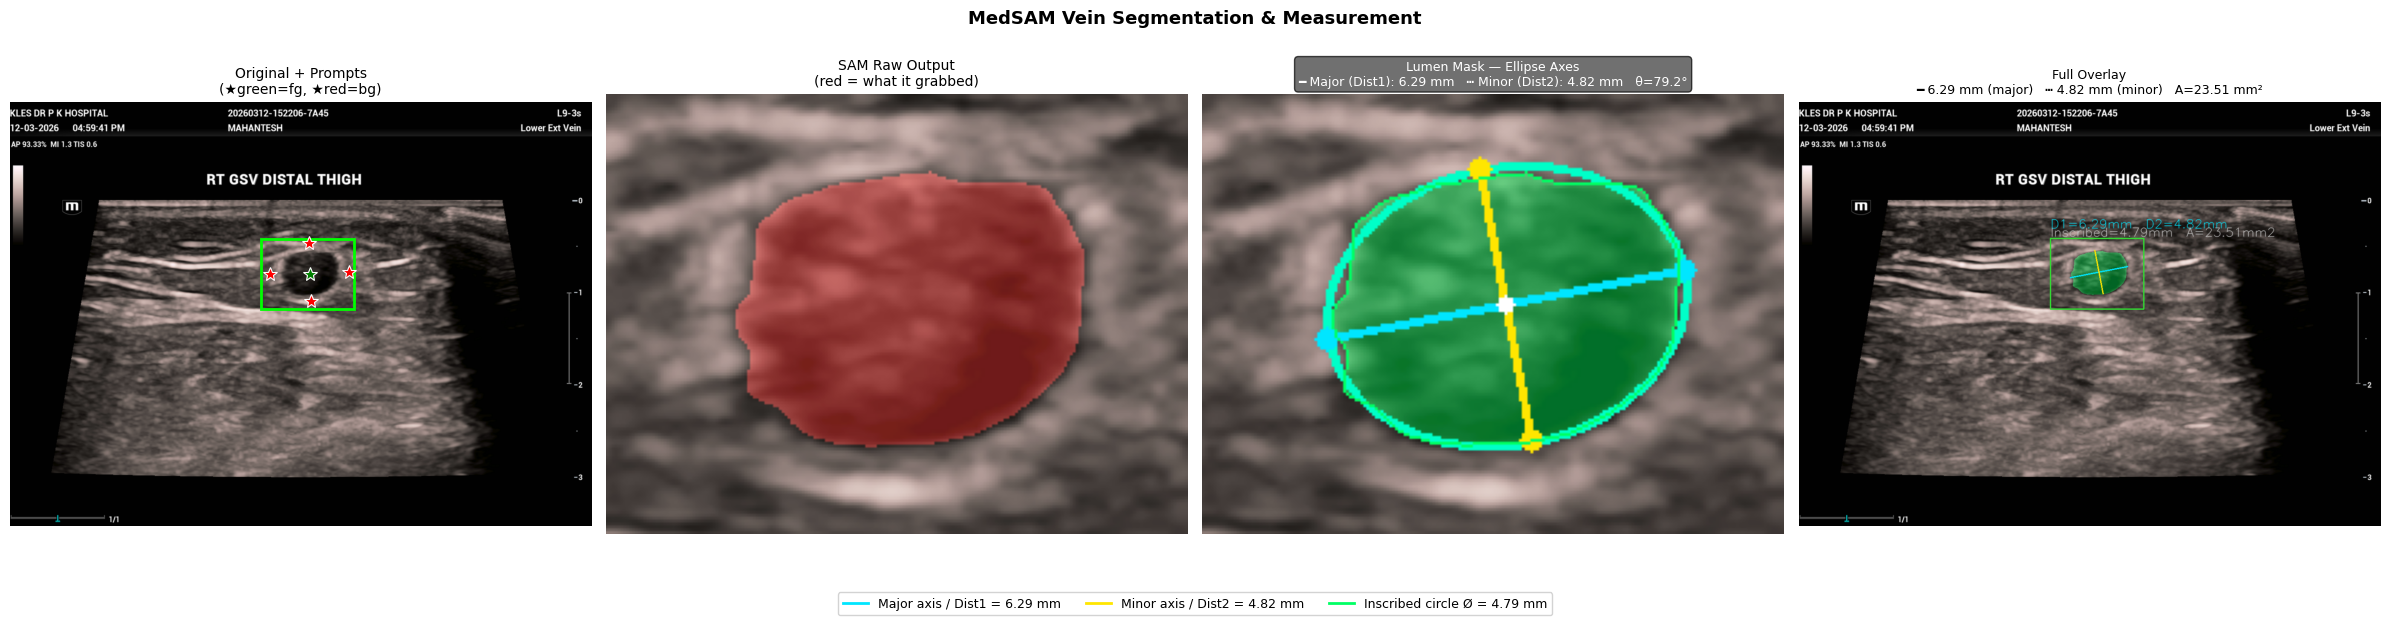

In [17]:
def visualise_results(img_rgb, mask, mask_original, bbox, measurements,
                      pos_pts=None, neg_pts=None, save_path=None):
    x1, y1, x2, y2 = bbox
    pos_pts = pos_pts or []
    neg_pts = neg_pts or []

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # ── Panel 1: Original + bbox + prompt points ──────────────────────────
    axes[0].imshow(img_rgb, cmap="gray" if img_rgb.ndim == 2 else None)
    axes[0].add_patch(patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor="lime", facecolor="none"
    ))
    for (px, py) in pos_pts:
        axes[0].plot(px, py, 'g*', markersize=10, markeredgecolor='white', markeredgewidth=0.8)
    for (px, py) in neg_pts:
        axes[0].plot(px, py, 'r*', markersize=10, markeredgecolor='white', markeredgewidth=0.8)
    axes[0].set_title("Original + Prompts\n(★green=fg, ★red=bg)", fontsize=10)
    axes[0].axis("off")

    # ── Panel 2: SAM raw output ───────────────────────────────────────────
    roi_orig = img_rgb[y1:y2, x1:x2].copy()
    red_lyr  = np.zeros_like(roi_orig)
    red_lyr[mask_original[y1:y2, x1:x2]] = [220, 50, 50]
    p2 = cv2.addWeighted(roi_orig, 1.0, red_lyr, 0.5, 0)
    axes[1].imshow(p2)
    axes[1].set_title("SAM Raw Output\n(red = what it grabbed)", fontsize=10)
    axes[1].axis("off")

    # ── Panel 3: Lumen mask + ellipse axes drawn ──────────────────────────
    roi_img  = img_rgb[y1:y2, x1:x2].copy()
    roi_mask = mask[y1:y2, x1:x2]
    grn_lyr  = np.zeros_like(roi_img)
    grn_lyr[roi_mask] = [0, 220, 80]
    p3 = cv2.addWeighted(roi_img, 1.0, grn_lyr, 0.5, 0)

    mask_u8 = roi_mask.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    ellipse_params = None
    if contours:
        c = max(contours, key=cv2.contourArea)
        if len(c) >= 5:
            ellipse_params = cv2.fitEllipse(c)
            cv2.ellipse(p3, ellipse_params, (0, 255, 200), 2)

            # Draw major and minor axis lines on the ROI
            (ecx, ecy), (ew, eh), eangle = ellipse_params
            angle_rad = np.deg2rad(eangle)

            # Half-lengths in pixels
            half_major = max(ew, eh) / 2.0
            half_minor = min(ew, eh) / 2.0

            # Major axis direction: along the longer dimension
            if ew >= eh:
                maj_cos, maj_sin = np.cos(angle_rad), np.sin(angle_rad)
            else:
                maj_cos, maj_sin = -np.sin(angle_rad), np.cos(angle_rad)
            min_cos = -maj_sin
            min_sin =  maj_cos

            # Major axis endpoints
            maj_x1 = int(ecx - half_major * maj_cos)
            maj_y1 = int(ecy - half_major * maj_sin)
            maj_x2 = int(ecx + half_major * maj_cos)
            maj_y2 = int(ecy + half_major * maj_sin)

            # Minor axis endpoints
            minn_x1 = int(ecx - half_minor * min_cos)
            minn_y1 = int(ecy - half_minor * min_sin)
            minn_x2 = int(ecx + half_minor * min_cos)
            minn_y2 = int(ecy + half_minor * min_sin)

            # Draw axes: cyan = major (Dist1), yellow = minor (Dist2)
            cv2.line(p3, (maj_x1, maj_y1), (maj_x2, maj_y2),  (0, 230, 255), 2)   # cyan
            cv2.line(p3, (minn_x1, minn_y1), (minn_x2, minn_y2), (255, 230, 0), 2) # yellow

            # Endpoint dots
            for pt in [(maj_x1, maj_y1), (maj_x2, maj_y2)]:
                cv2.circle(p3, pt, 4, (0, 230, 255), -1)
            for pt in [(minn_x1, minn_y1), (minn_x2, minn_y2)]:
                cv2.circle(p3, pt, 4, (255, 230, 0), -1)

            # Centre dot
            cv2.circle(p3, (int(ecx), int(ecy)), 3, (255, 255, 255), -1)

        cv2.drawContours(p3, contours, -1, (0, 255, 100), 1)

    # Label the axes in matplotlib (avoids tiny cv2 text)
    axes[2].imshow(p3)
    major_mm = measurements.get("ellipse_major_diameter_mm")
    minor_mm = measurements.get("ellipse_minor_diameter_mm")
    angle_deg = measurements.get("ellipse_angle_deg")
    title3 = "Lumen Mask — Ellipse Axes\n"
    if major_mm and minor_mm:
        title3 += f"━ Major (Dist1): {major_mm:.2f} mm   ┅ Minor (Dist2): {minor_mm:.2f} mm"
    if angle_deg is not None:
        title3 += f"   θ={angle_deg:.1f}°"
    axes[2].set_title(title3, fontsize=9, color="white",
                      bbox=dict(boxstyle="round,pad=0.3", fc="#333333", alpha=0.7))
    axes[2].axis("off")

    # ── Panel 4: Full image overlay with both diameters annotated ─────────
    full_overlay = img_rgb.copy()
    g_full       = np.zeros_like(full_overlay)
    g_full[mask] = [0, 220, 80]
    blended = cv2.addWeighted(
        full_overlay[y1:y2, x1:x2], 1.0,
        g_full[y1:y2, x1:x2],       0.45, 0
    )
    full_overlay[y1:y2, x1:x2] = blended
    cv2.rectangle(full_overlay, (x1, y1), (x2, y2), (50, 220, 50), 2)

    # Draw ellipse axes on full image too (offset by bbox origin)
    if ellipse_params is not None:
        (ecx, ecy), (ew, eh), eangle = ellipse_params
        ecx_full, ecy_full = ecx + x1, ecy + y1
        angle_rad = np.deg2rad(eangle)
        half_major = max(ew, eh) / 2.0
        half_minor = min(ew, eh) / 2.0
        if ew >= eh:
            maj_cos, maj_sin = np.cos(angle_rad), np.sin(angle_rad)
        else:
            maj_cos, maj_sin = -np.sin(angle_rad), np.cos(angle_rad)
        min_cos = -maj_sin
        min_sin =  maj_cos

        cv2.line(full_overlay,
                 (int(ecx_full - half_major * maj_cos), int(ecy_full - half_major * maj_sin)),
                 (int(ecx_full + half_major * maj_cos), int(ecy_full + half_major * maj_sin)),
                 (0, 230, 255), 2)   # cyan = major
        cv2.line(full_overlay,
                 (int(ecx_full - half_minor * min_cos), int(ecy_full - half_minor * min_sin)),
                 (int(ecx_full + half_minor * min_cos), int(ecy_full + half_minor * min_sin)),
                 (255, 230, 0), 2)   # yellow = minor

    area_mm2 = measurements.get("area_mm2", 0)
    font_scale = max(0.35, img_rgb.shape[1] / 1400)

    # Two annotation lines: primary ellipse diameters + secondary dist-transform
    dist_mm = measurements.get("distance_transform_diameter_mm", 0)
    label1 = f"D1={major_mm:.2f}mm  D2={minor_mm:.2f}mm" if major_mm and minor_mm else ""
    label2 = f"Inscribed={dist_mm:.2f}mm  A={area_mm2:.2f}mm2"

    text_y = max(y1 - 22, 20)
    cv2.putText(full_overlay, label1, (x1, text_y),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 230, 255), 1, cv2.LINE_AA)
    cv2.putText(full_overlay, label2, (x1, text_y + 18),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (200, 200, 200), 1, cv2.LINE_AA)

    axes[3].imshow(full_overlay)
    title4 = "Full Overlay\n"
    if major_mm and minor_mm:
        title4 += f"━ {major_mm:.2f} mm (major)   ┅ {minor_mm:.2f} mm (minor)   A={area_mm2:.2f} mm²"
    axes[3].set_title(title4, fontsize=9)
    axes[3].axis("off")

    # ── Legend ────────────────────────────────────────────────────────────
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=(0/255, 230/255, 255/255), linewidth=2,
               label=f'Major axis / Dist1 = {major_mm:.2f} mm' if major_mm else 'Major axis'),
        Line2D([0], [0], color=(255/255, 230/255, 0/255), linewidth=2,
               label=f'Minor axis / Dist2 = {minor_mm:.2f} mm' if minor_mm else 'Minor axis'),
        Line2D([0], [0], color=(0/255, 255/255, 100/255), linewidth=2,
               label=f'Inscribed circle Ø = {dist_mm:.2f} mm'),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=3,
               fontsize=9, framealpha=0.85,
               bbox_to_anchor=(0.5, -0.04))

    plt.suptitle("MedSAM Vein Segmentation & Measurement", fontsize=13, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[VIZ] Saved to {save_path}")

    plt.show()


# ── Run visualisation ─────────────────────────────────────────────────────
visualise_results(
    img_rgb, mask, mask_original,
    bounding_box.tolist(), measurements,
    pos_pts=pos_points, neg_pts=neg_points,
    save_path="/content/vein_result.png"
)